# 08 — Wind Tile Merge Strategies

When a simulation area is larger than one tile, the SDK breaks it into overlapping 512 m tiles,
runs each tile independently, then **stitches the results back together**.

The default stitch simply crops each tile to its centre half and places them side by side.
That works well, but it ignores the wind direction — and wind simulations are *directional*:
the tile that sat **upwind** during the simulation has richer, more accurate data in the overlap
zone than the tile that sat downwind.

Two smarter strategies exploit that:

| Strategy | What it does |
|---|---|
| `"default"` | Centre-crop. Fast, direction-agnostic. |
| `"directional"` | In the overlap, picks the upwind tile's value at every cell (hard switch). |
| `"directional_blend"` | Same logic, but smoothly fades between the two tiles instead of a hard switch. |

This notebook runs a single wind simulation on a multi-tile polygon, then merges it three ways
so you can compare the results directly.

In [1]:
from dotenv import load_dotenv

load_dotenv()

import time
import numpy as np
import matplotlib.pyplot as plt

from infrared_sdk import InfraredClient
from infrared_sdk.analyses.types import AnalysesName, WindModelRequest

# Munich city centre — ~640 m wide, ~320 m tall.
# At the wind step of 256 m this produces a 2×3 tile grid (6 tiles), giving
# clearly visible overlap seams to compare across merge strategies.
# Swap in any polygon of your own; just make sure it spans at least 512 m in
# the wind direction so there is more than one tile to stitch.
POLYGON = {
    "type": "Polygon",
    "coordinates": [
        [
            [16.3636, 48.1954],
            [16.3744, 48.1954],
            [16.3744, 48.2026],
            [16.3636, 48.2026],
            [16.3636, 48.1954],
        ]
    ],
}
CITY_NAME = "Vienna"
WIND_DIR = 33.0  # meteorological: wind FROM the west, blowing eastward

## 1. Submit the wind simulation

We use the lower-level `run_area` / `check_area_state` pair (instead of `run_area_and_wait`)
so we can call `merge_area_jobs` three times with different strategies on the same finished schedule.

In [2]:
with InfraredClient() as client:
    area = client.buildings.get_area(POLYGON)

    schedule = client.run_area(
        WindModelRequest(
            analysis_type=AnalysesName.wind_speed,
            wind_speed=5,
            wind_direction=int(WIND_DIR),
        ),
        POLYGON,
        buildings=area.buildings,
    )
    n_jobs = len(schedule.jobs)
    print(f"submitted {n_jobs} tile job(s) — polling …")

    time.sleep(4)  # let the API register jobs before first poll
    while True:
        state = client.check_area_state(schedule)
        print(
            f"  running={state.running}  succeeded={state.succeeded}  failed={state.failed}",
            end="\r",
        )
        if state.running == 0 and (state.succeeded + state.failed) >= n_jobs:
            break
        time.sleep(8)

    print(f"\ndone — {state.succeeded} succeeded, {state.failed} failed")

submitted 16 tile job(s) — polling …
  running=0  succeeded=16  failed=0
done — 16 succeeded, 0 failed


## 2. Merge three ways

The schedule object is reusable — the tile results are already on the server.
Calling `merge_area_jobs` is cheap: it just downloads and stitches.

In [3]:
with InfraredClient() as client:
    result_default = client.merge_area_jobs(schedule)

    result_directional = client.merge_area_jobs(
        schedule,
        strategy="directional",
        wind_direction_deg=WIND_DIR,
    )

    result_blend = client.merge_area_jobs(
        schedule,
        strategy="directional_blend",
        wind_direction_deg=WIND_DIR,
    )

grids = {
    "default": result_default.merged_grid,
    "directional": result_directional.merged_grid,
    "directional_blend": result_blend.merged_grid,
}
print("merged grid shape:", result_default.merged_grid.shape)

merged grid shape: (1024, 1024)


## 3. Side-by-side comparison

The difference map (`directional_blend − default`) highlights where the merge strategy changed the result.
Changes are concentrated in the overlap zones between tiles.

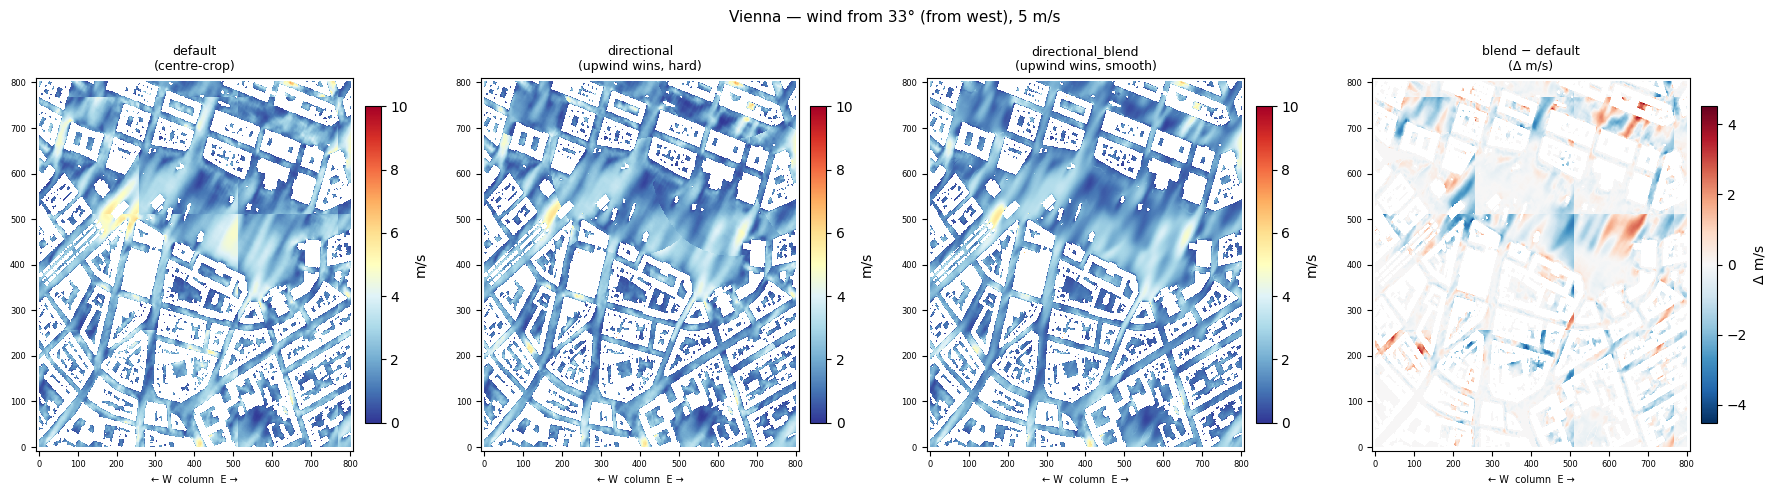

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Compute valid data extent from the default grid (same for all three)
valid = ~np.isnan(grids["default"])
rows = np.any(valid, axis=1)
cols = np.any(valid, axis=0)
r0, r1 = np.where(rows)[0][[0, -1]]
c0, c1 = np.where(cols)[0][[0, -1]]
pad = 8  # small border so the edge pixels aren't clipped

vmin = np.nanpercentile(result_default.merged_grid, 2)
vmax = np.nanpercentile(result_default.merged_grid, 98)
cmap = plt.cm.RdYlBu_r

titles = [
    "default\n(centre-crop)",
    "directional\n(upwind wins, hard)",
    "directional_blend\n(upwind wins, smooth)",
]
for ax, (name, grid), title in zip(axes[:3], grids.items(), titles):
    im = ax.imshow(
        grid,
        cmap=cmap,
        vmin=0,
        vmax=10,
        origin="lower",
        interpolation="nearest",
        aspect="auto",
    )
    ax.set_xlim(c0 - pad, c1 + pad)
    ax.set_ylim(r0 - pad, r1 + pad)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("← W  column  E →", fontsize=7)
    ax.tick_params(labelsize=6)
    fig.colorbar(im, ax=ax, shrink=0.85, label="m/s", pad=0.03)

diff = grids["directional_blend"] - grids["default"]
dmax = max(np.nanmax(np.abs(diff)), 0.1)
im_d = axes[3].imshow(
    diff,
    cmap=plt.cm.RdBu_r,
    vmin=-dmax,
    vmax=dmax,
    origin="lower",
    interpolation="nearest",
    aspect="auto",
)
axes[3].set_xlim(c0 - pad, c1 + pad)
axes[3].set_ylim(r0 - pad, r1 + pad)
axes[3].set_title("blend − default\n(Δ m/s)", fontsize=9)
axes[3].set_xlabel("← W  column  E →", fontsize=7)
axes[3].tick_params(labelsize=6)
fig.colorbar(im_d, ax=axes[3], shrink=0.85, label="Δ m/s", pad=0.03)

fig.suptitle(
    f"{CITY_NAME} — wind from {int(WIND_DIR)}° (from west), 5 m/s", fontsize=11
)
plt.tight_layout()
plt.show()

## Which strategy should I use?

**`"default"`** is always safe. Use it when wind direction is uncertain, for non-wind analyses,
or when you just want the fastest path to a result.

**`"directional"`** is the right choice when you have a single, well-defined wind direction
and want the most physically correct values at tile boundaries without any smoothing.

**`"directional_blend"`** is the same idea with a smooth transition — better for visualisation
and downstream processing where hard steps across tile seams would be distracting.

Both directional strategies are particularly valuable when you run **extra tiles** beyond the
default grid — for example, higher coverage over a specific courtyard, a densely sampled
corridor, or a custom non-uniform grid. The default centre-crop only works cleanly on a
regular step grid; the directional strategies handle any overlap correctly because they reason
about *which tile was upwind*, not about tile position.